In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import random

#  Custom dataset: MNIST + random rotation angle annotation
class RotatedMNIST(Dataset):
    def __init__(self, train=True):
        self.mnist = datasets.MNIST(root='./data', train=train, download=True)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        self.train = train

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, _ = self.mnist[idx]  #
        angle = random.uniform(0, 90)  # generate random angles
        img_rotated = img.rotate(angle)
        img_rotated = img_rotated.convert("RGB")  # ResNet requires 3 channels
        img_tensor = self.transform(img_rotated)
        return img_tensor, torch.tensor(angle, dtype=torch.float32)

#  Data loading
train_ds = RotatedMNIST(train=True)
test_ds = RotatedMNIST(train=False)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

#  修改 ResNet18 為回歸模型 / Modify ResNet18 to a regression model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 1)
model.to(device)

# training settings
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# training model
for epoch in range(5):
    model.train()
    total_loss = 0
    for imgs, angles in train_loader:
        imgs, angles = imgs.to(device), angles.to(device).unsqueeze(1)
        preds = model(imgs)
        loss = loss_fn(preds, angles)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    print(f"Epoch {epoch+1}, Train Loss: {total_loss / len(train_loader.dataset):.2f}")

# MAE Evaluation
model.eval()
from sklearn.metrics import mean_absolute_error
preds, truths = [], []
with torch.no_grad():
    for imgs, angles in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).cpu().squeeze()
        preds.extend(outputs.numpy())
        truths.extend(angles.numpy())
print("Test MAE:", mean_absolute_error(truths, preds))


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.57MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:

Epoch 1, Train Loss: 663.06
Epoch 2, Train Loss: 429.42
Epoch 3, Train Loss: 354.54
Epoch 4, Train Loss: 313.02
Epoch 5, Train Loss: 292.93
Test MAE: 12.907034392201528


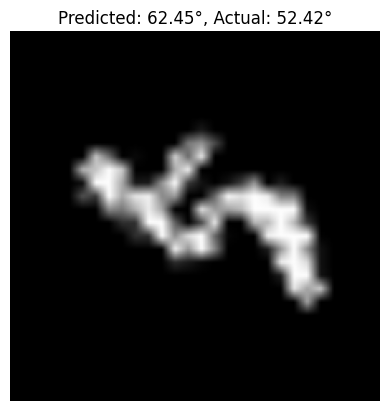

Wrong! error: 10.03° ≥ 5.0°


In [8]:
import matplotlib.pyplot as plt
import random

# Randomly select a picture, make single picture prediction and display
def predict_random_image(model, dataset, threshold=5.0):
    model.eval()
    idx = random.randint(0, len(dataset) - 1)
    img_tensor, true_angle = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_angle = model(input_tensor).cpu().item()

    # Visualization
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)  # denormalization

    plt.imshow(img_np)
    plt.title(f"Predicted: {pred_angle:.2f}°, Actual: {true_angle:.2f}°")
    plt.axis('off')
    plt.show()

    # Judging whether it is correct or not
    if abs(pred_angle - true_angle.item()) < threshold:
        print(f"Correct! error: {abs(pred_angle - true_angle.item()):.2f}° < {threshold}°")
    else:
        print(f"Wrong! error: {abs(pred_angle - true_angle.item()):.2f}° ≥ {threshold}°")

# prediction
predict_random_image(model, test_ds)
